In [1]:
import os
os.environ['KAGGLE_USERNAME'] = "fazilmf"
os.environ['KAGGLE_KEY'] = "KGAT_016675489f4e79ad181a2160f4e7661f"

In [2]:
!kaggle datasets download -d fedesoriano/electric-power-consumption

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption
License(s): copyright-authors
100% 1.36M/1.36M [00:00<00:00, 92.5MB/s]



In [3]:
!unzip electric-power-consumption.zip -d/content

Archive:  electric-power-consumption.zip
  inflating: /content/powerconsumption.csv  


In [4]:
import pandas as pd
df = pd.read_csv('powerconsumption.csv')
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [5]:
df.tail()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
52411,12/30/2017 23:10,7.010,72.4,0.080,0.040,0.096,31160.45627,26857.31820,14780.31212
52412,12/30/2017 23:20,6.947,72.6,0.082,0.051,0.093,30430.41825,26124.57809,14428.81152
52413,12/30/2017 23:30,6.900,72.8,0.086,0.084,0.074,29590.87452,25277.69254,13806.48259
52414,12/30/2017 23:40,6.758,73.0,0.080,0.066,0.089,28958.17490,24692.23688,13512.60504
52415,12/30/2017 23:50,6.580,74.1,0.081,0.062,0.111,28349.80989,24055.23167,13345.49820


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [7]:
df.describe()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


In [8]:
df.isnull().sum()

,0
Datetime,0
Temperature,0
Humidity,0
WindSpeed,0
GeneralDiffuseFlows,0
DiffuseFlows,0
PowerConsumption_Zone1,0
PowerConsumption_Zone2,0
PowerConsumption_Zone3,0


In [9]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df["hour"] = df["Datetime"].dt.hour
df["day"] = df["Datetime"].dt.day
df["month"] = df["Datetime"].dt.month

In [10]:
df["Total_Power"] = (df["PowerConsumption_Zone1"] +df["PowerConsumption_Zone2"] +df["PowerConsumption_Zone3"])

In [11]:
df.drop(["PowerConsumption_Zone1","PowerConsumption_Zone2","PowerConsumption_Zone3"],axis=1,inplace=True)

In [12]:
df.drop(["Datetime"],axis=1,inplace=True)

In [13]:
x = df.drop(["Total_Power"],axis=1)
y = df["Total_Power"]

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [15]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train,y_train)

RandomForestRegressor()

In [16]:
y_pred = model.predict(x_test)

In [17]:
import numpy as np
from sklearn.metrics import r2_score,mean_squared_error
print(r2_score(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

0.9833923913927786
2215.4342056341775


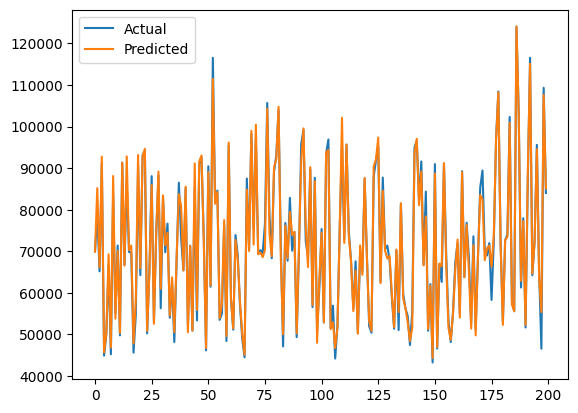

In [18]:
import matplotlib.pyplot as plt
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.show()

In [19]:
from xgboost import XGBRegressor
xgb = XGBRegressor( n_estimators=200,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=42)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

In [20]:
import numpy as np
print("XGBoost RMSE:",np.sqrt(mean_squared_error(y_test, xgb_pred)))


XGBoost RMSE: 3092.495550654402


In [21]:
import pickle
with open("model.pkl","wb") as f:
  pickle.dump(model,f)

In [22]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>